In [1]:
import tensorflow as tf
print("Num GPUs:", len(tf.config.list_physical_devices("GPU")))

Num GPUs: 1


In [2]:
from google.colab import files
uploaded = files.upload()

Saving IMG.zip to IMG (1).zip


In [4]:
!unzip IMG.zip

Streaming output truncated to the last 5000 lines.
  inflating: IMG/right_2026_08_04_10_18_36_653.jpg  
  inflating: IMG/right_2026_08_04_10_18_36_726.jpg  
  inflating: IMG/right_2026_08_04_10_18_36_799.jpg  
  inflating: IMG/right_2026_08_04_10_18_36_871.jpg  
  inflating: IMG/right_2026_08_04_10_18_36_942.jpg  
  inflating: IMG/right_2026_08_04_10_18_37_016.jpg  
  inflating: IMG/right_2026_08_04_10_18_37_088.jpg  
  inflating: IMG/right_2026_08_04_10_18_37_168.jpg  
  inflating: IMG/right_2026_08_04_10_18_37_238.jpg  
  inflating: IMG/right_2026_08_04_10_18_37_309.jpg  
  inflating: IMG/right_2026_08_04_10_18_37_385.jpg  
  inflating: IMG/right_2026_08_04_10_18_37_455.jpg  
  inflating: IMG/right_2026_08_04_10_18_37_529.jpg  
  inflating: IMG/right_2026_08_04_10_18_37_611.jpg  
  inflating: IMG/right_2026_08_04_10_18_37_687.jpg  
  inflating: IMG/right_2026_08_04_10_18_37_756.jpg  
  inflating: IMG/right_2026_08_04_10_18_37_828.jpg  
  inflating: IMG/right_2026_08_04_10_18_37_896.j

In [7]:
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

# Re-define paths to ensure they are correct
base_dir = '/content'
csv_path = os.path.join(base_dir, 'driving_log.csv')
img_dir = os.path.join(base_dir, 'IMG')

# 1. Load the CSV
columns = ['center', 'left', 'right', 'steering', 'throttle', 'brake', 'speed']
df = pd.read_csv(csv_path, names=columns, header=None, skipinitialspace=True)

# If the first row is actually the text header, drop it
if df.iloc[0]['center'] == 'center':
    df = df.iloc[1:].reset_index(drop=True)

# 2. Keep ONLY center camera and steering angle
center_df = df[['center', 'steering']].copy()

# 3. Fix image paths (handles both Windows and Mac/Linux paths from the simulator)
def get_image_path(csv_path):
    filename = csv_path.split('/')[-1].strip()
    filename = filename.split('\\')[-1].strip()
    full_path = os.path.join(img_dir, filename)
    return full_path

center_df['image_path'] = center_df['center'].apply(get_image_path)
center_df['steering'] = center_df['steering'].astype(float)

# 4. Drop rows where the image doesn't actually exist on disk
center_df = center_df[center_df['image_path'].apply(os.path.exists)].reset_index(drop=True)

print(f"✅ Total Center Camera Samples Ready for Training: {len(center_df)}")
display(center_df.head())

✅ Total Center Camera Samples Ready for Training: 7635


,center,steering,image_path
0,C:\Users\Student\Desktop\nirmancv\IMG\center_2...,0.0,/content/IMG/center_2026_08_04_10_05_05_381.jpg
1,C:\Users\Student\Desktop\nirmancv\IMG\center_2...,0.0,/content/IMG/center_2026_08_04_10_05_05_447.jpg
2,C:\Users\Student\Desktop\nirmancv\IMG\center_2...,0.0,/content/IMG/center_2026_08_04_10_05_05_516.jpg
3,C:\Users\Student\Desktop\nirmancv\IMG\center_2...,0.0,/content/IMG/center_2026_08_04_10_05_05_587.jpg
4,C:\Users\Student\Desktop\nirmancv\IMG\center_2...,0.0,/content/IMG/center_2026_08_04_10_05_05_655.jpg


In [8]:
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

# Split into 80% Train, 20% Validation
train_df, val_df = train_test_split(center_df, test_size=0.2, random_state=42)

# NVIDIA Preprocessing Parameters
IMG_HEIGHT = 66
IMG_WIDTH = 200
CROP_TOP = 60     # Crop out sky/trees
CROP_BOTTOM = 135 # Crop out car hood

def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Crop sky and hood
    img = img[CROP_TOP:CROP_BOTTOM, :]

    # Resize to NVIDIA standard (66x200)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_AREA)

    return img

def augment_image(image, steering_angle):
    # Random horizontal flip (50% chance)
    if np.random.rand() < 0.5:
        image = cv2.flip(image, 1)
        steering_angle = -steering_angle # MUST flip steering if image flips

    return image, steering_angle

class NvidiaDataGenerator(Sequence):
    def __init__(self, dataframe, batch_size=32, is_training=True):
        self.df = dataframe
        self.batch_size = batch_size
        self.is_training = is_training
        self.indexes = np.arange(len(self.df))

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indexes]

        images = []
        steerings = []

        for _, row in batch_df.iterrows():
            img = preprocess_image(row['image_path'])
            steering = float(row['steering'])

            if self.is_training:
                img, steering = augment_image(img, steering)

            images.append(img)
            steerings.append(steering)

        return np.array(images), np.array(steerings)

    def on_epoch_end(self):
        if self.is_training:
            np.random.shuffle(self.indexes)

# Create Generators
train_gen = NvidiaDataGenerator(train_df, batch_size=32, is_training=True)
val_gen = NvidiaDataGenerator(val_df, batch_size=32, is_training=False)

print("✅ Train and Validation Generators created successfully.")
print(f"Training batches: {len(train_gen)}, Validation batches: {len(val_gen)}")

✅ Train and Validation Generators created successfully.
Training batches: 191, Validation batches: 48


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout, Lambda

def build_nvidia_model():
    model = Sequential()

    # 1. Normalization Layer (maps [0, 255] to [-1, 1])
    model.add(Lambda(lambda x: (x / 127.5) - 1.0, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

    # 2. Convolutional Layers
    model.add(Conv2D(24, (5, 5), strides=(2, 2), activation='elu'))
    model.add(Conv2D(36, (5, 5), strides=(2, 2), activation='elu'))
    model.add(Conv2D(48, (5, 5), strides=(2, 2), activation='elu'))
    model.add(Conv2D(64, (3, 3), activation='elu'))
    model.add(Conv2D(64, (3, 3), activation='elu'))

    # 3. Flatten
    model.add(Flatten())

    # 4. Fully Connected Layers
    model.add(Dense(100, activation='elu'))
    model.add(Dropout(0.2)) # Prevents overfitting
    model.add(Dense(50, activation='elu'))
    model.add(Dense(10, activation='elu'))

    # 5. Output Layer (Single value: Steering Angle)
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')
    return model

model = build_nvidia_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 66, 200, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 31, 98, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 47, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 22, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 20, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 1, 18, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,219 (985.23 KB)

 Trainable params: 252,219 (985.23 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    # Changed extension to .h5
    ModelCheckpoint('nvidia_center_camera_best.h5', save_best_only=True, monitor='val_loss')
]

print("Starting training... (This may take a few minutes depending on your dataset size)")

# Train the model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

Starting training... (This may take a few minutes depending on your dataset size)
Epoch 1/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0193

191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.0184 - val_loss: 0.0242
Epoch 2/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.0168 - val_loss: 0.0246
Epoch 3/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0162

191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: 0.0159 - val_loss: 0.0236
Epoch 4/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - loss: 0.0150 - val_loss: 0.0238
Epoch 5/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.0150 - val_loss: 0.0237
Epoch 6/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0148

191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.0148 - val_loss: 0.0235
Epoch 7/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: 0.0141 - val_loss: 0.0235
Epoch 8/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0140

191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.0134 - val_loss: 0.0234
Epoch 9/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.0134 - val_loss: 0.0243
Epoch 10/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0132 - val_loss: 0.0237
Epoch 11/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0125 - val_loss: 0.0242
Epoch 12/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.0123 - val_loss: 0.0245
Epoch 13/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - loss: 0.0119 - val_loss: 0.0247
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 8.


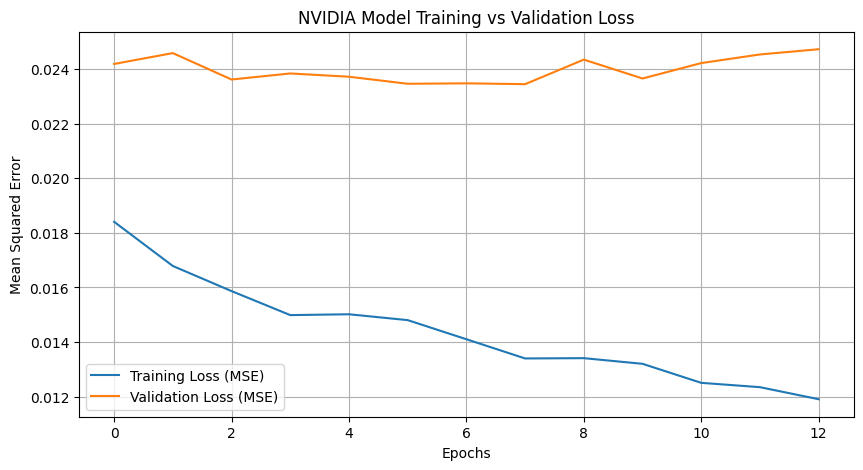

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('NVIDIA Model Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

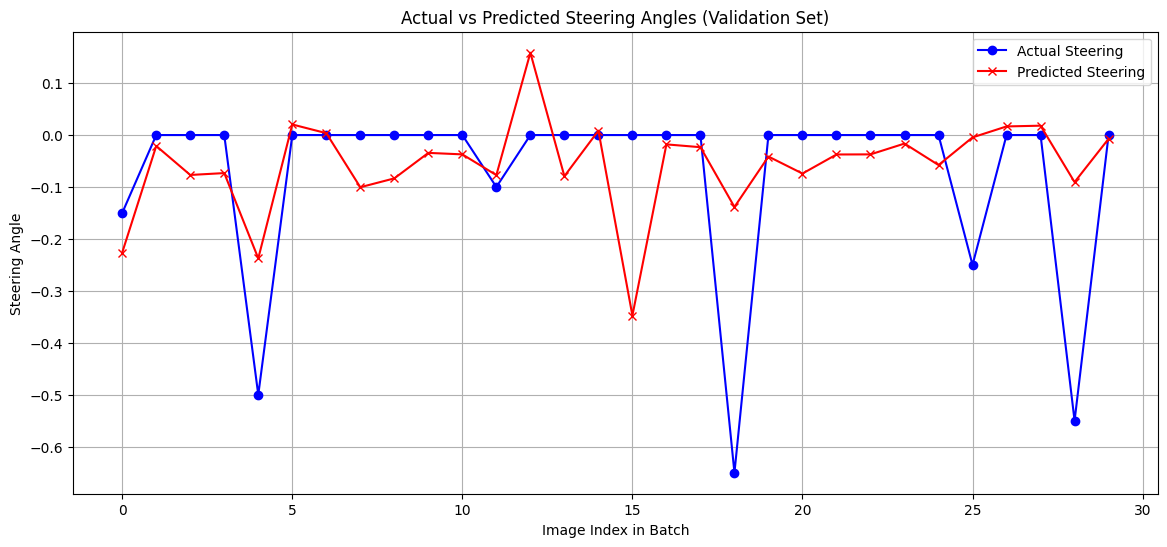

✅ Batch Mean Absolute Error (MAE): 0.0945


In [16]:
# Get one batch of validation images
val_images, val_steerings = val_gen[0]

# Predict steering angles
predicted_steerings = model.predict(val_images, verbose=0).flatten()

# Plot Actual vs Predicted for the first 30 images in the batch
plt.figure(figsize=(14, 6))
plt.plot(val_steerings[:30], label='Actual Steering', marker='o', color='blue')
plt.plot(predicted_steerings[:30], label='Predicted Steering', marker='x', color='red')
plt.title('Actual vs Predicted Steering Angles (Validation Set)')
plt.xlabel('Image Index in Batch')
plt.ylabel('Steering Angle')
plt.legend()
plt.grid(True)
plt.show()

# Print Mean Absolute Error for this batch
mae = np.mean(np.abs(val_steerings - predicted_steerings))
print(f"✅ Batch Mean Absolute Error (MAE): {mae:.4f}")

In [17]:
model_filename = 'nvidia_center_camera_best.h5'

print(f"Model saved as {model_filename}")
print("Downloading to your local computer...")

from google.colab import files
files.download(model_filename)

Model saved as nvidia_center_camera_best.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>